# Online Payments Fraud Detection using Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('fraud_detection.csv')

In [3]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [6]:
df.nunique()

step                   95
type                    5
amount            1009606
nameOrig          1048317
oldbalanceOrg      391033
newbalanceOrig     440792
nameDest           449635
oldbalanceDest     590110
newbalanceDest     437054
isFraud                 2
isFlaggedFraud          1
dtype: int64

In [7]:
object_columns = df.select_dtypes(include=['object', 'bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['type', 'nameOrig', 'nameDest'], dtype='str')

Numerical type columns:
Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='str')


In [8]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype in ['object', 'bool']:
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 10:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [9]:
categorical, non_categorical, discrete, continuous = classify_features(df)

In [10]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: []
Non-Categorical Features: []
Discrete Features: ['isFraud', 'isFlaggedFraud']
Continuous Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64
isFraud
0    1047433
1       1142
Name: count, dtype: int64
isFlaggedFraud
0    1048575
Name: count, dtype: int64


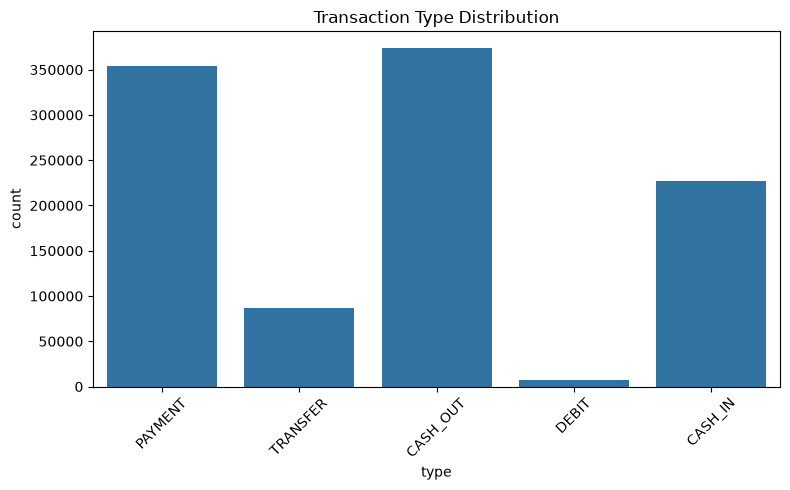

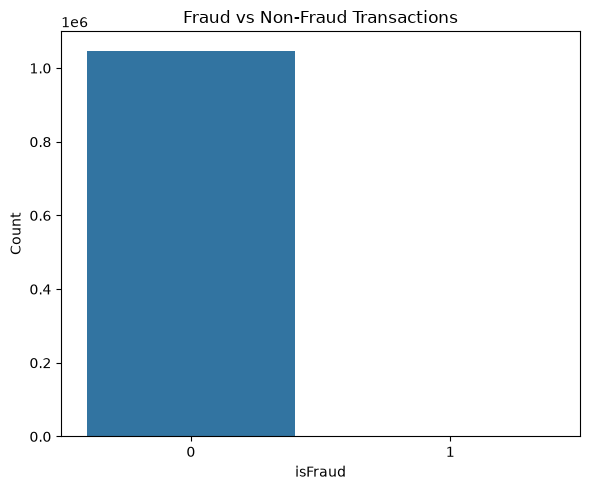

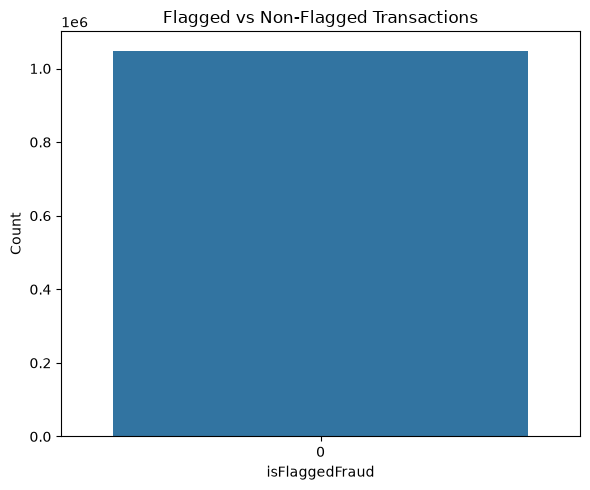

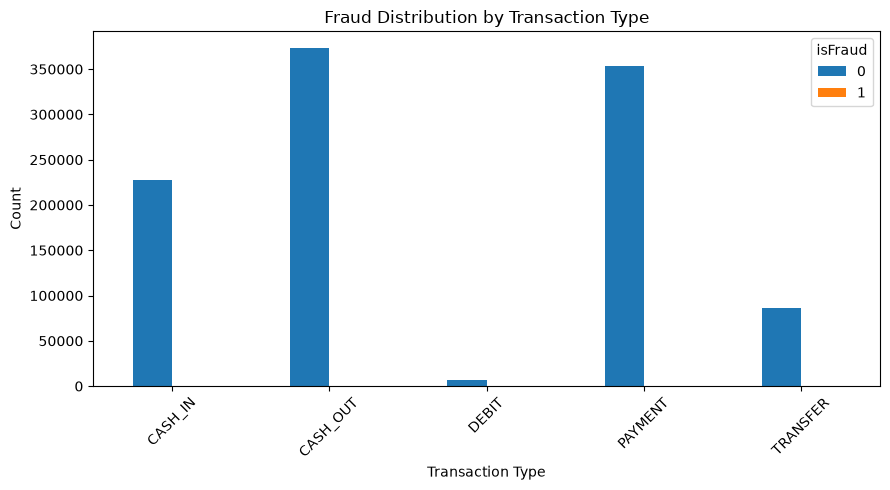

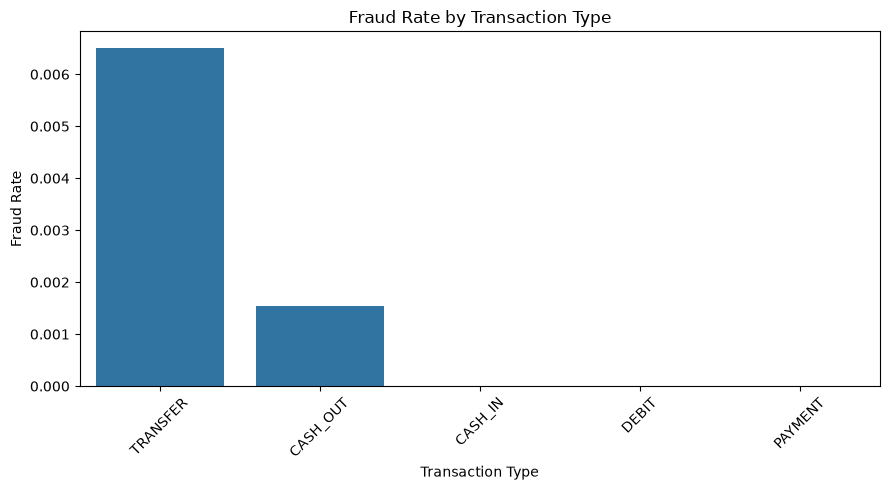

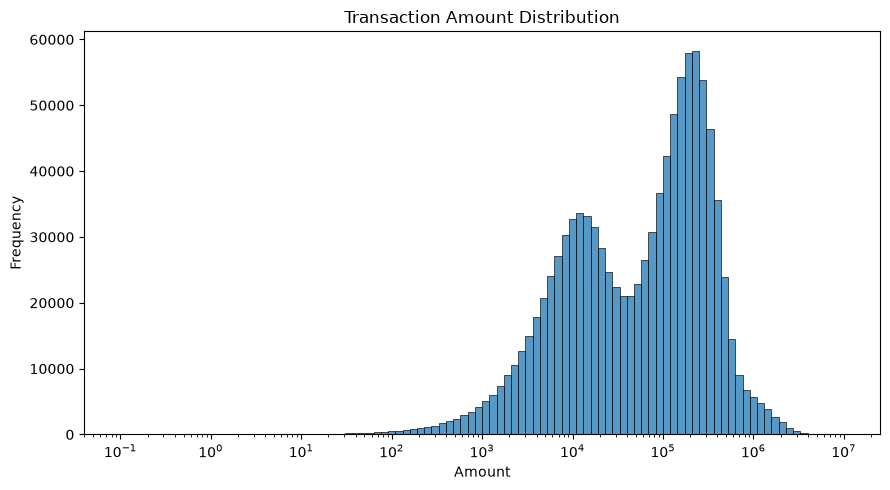

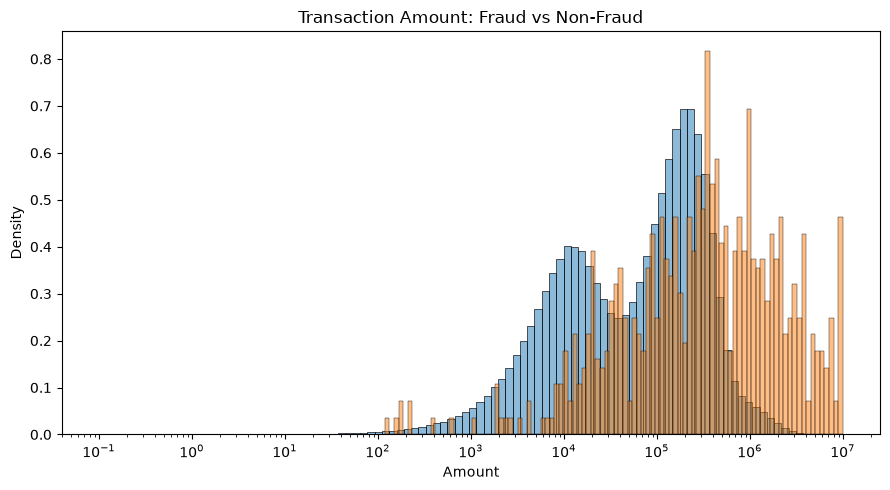

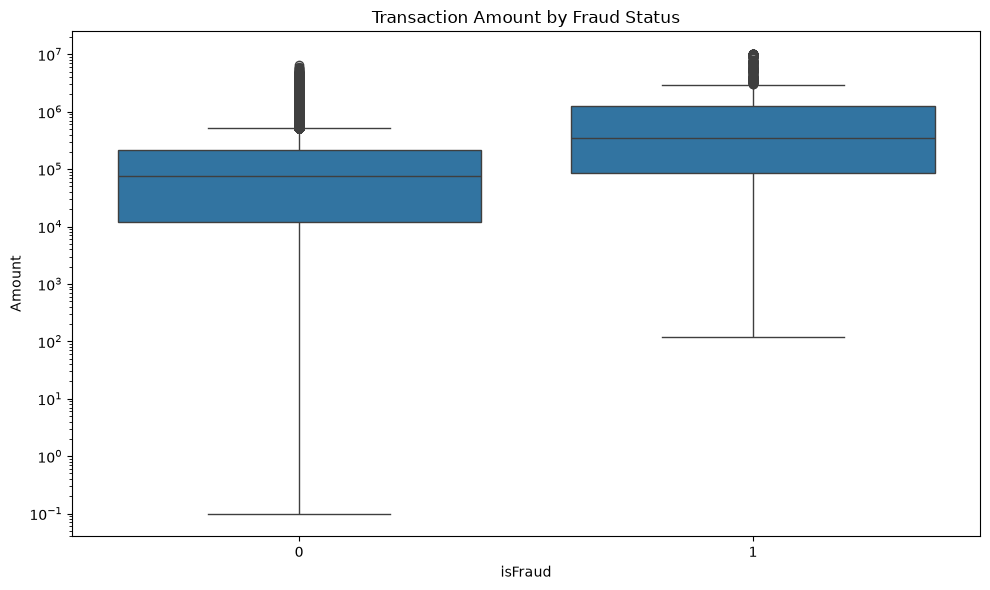

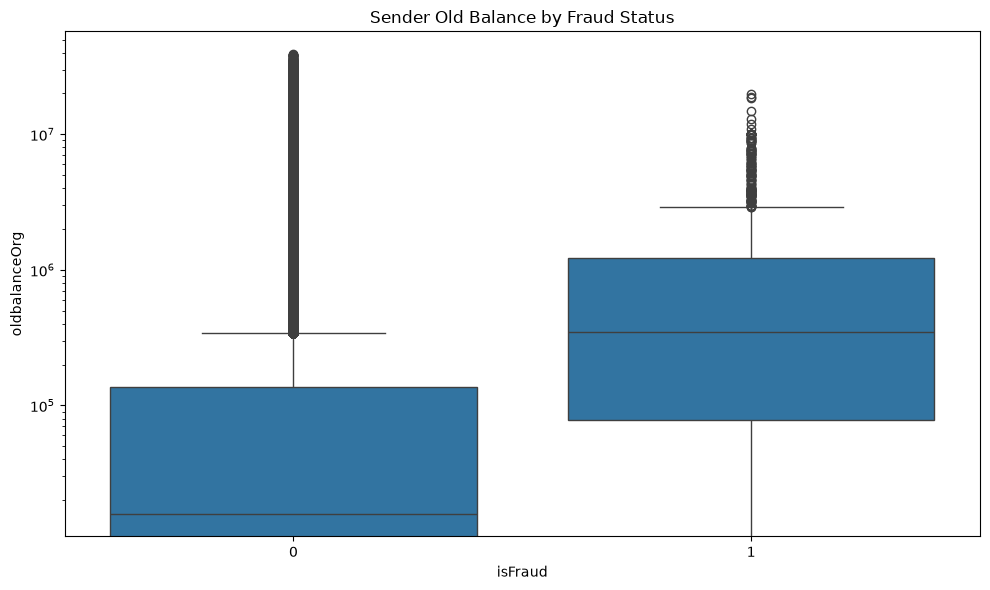

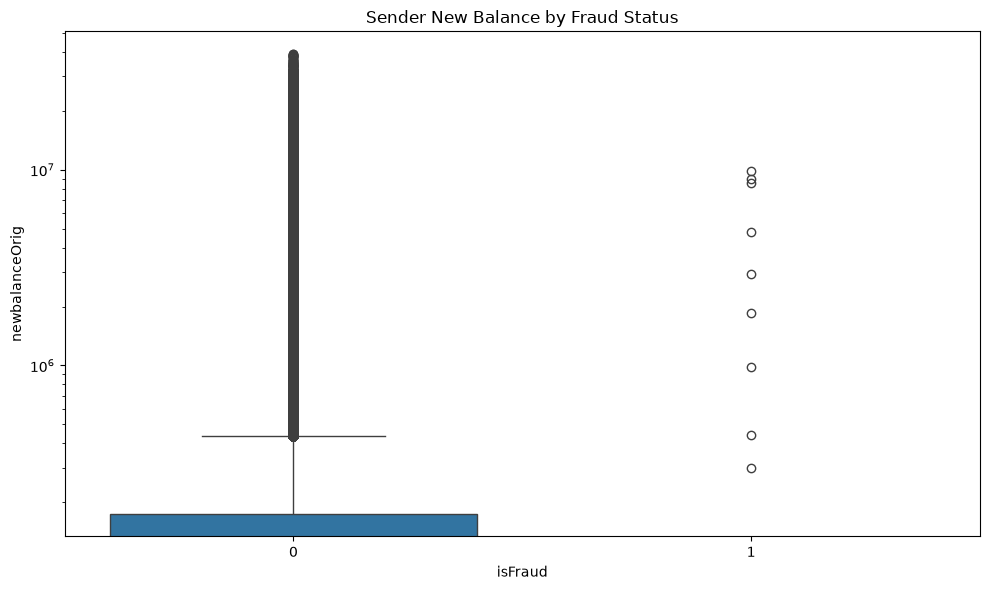

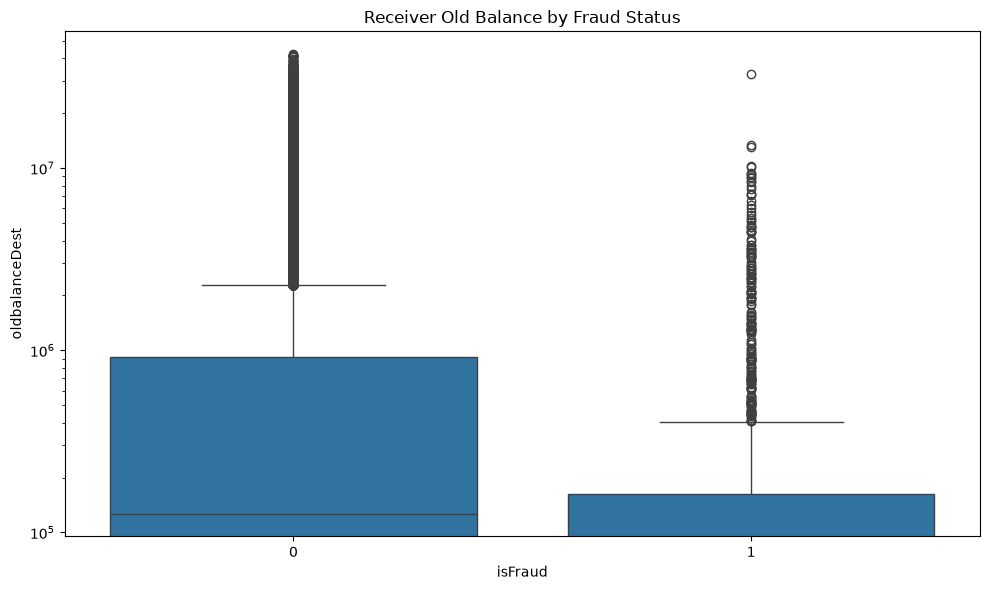

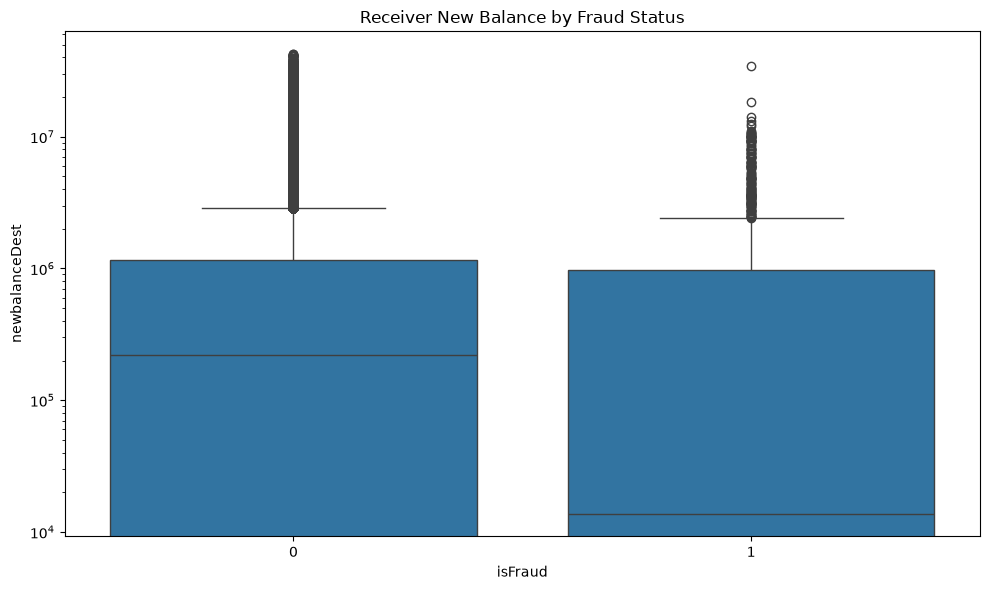

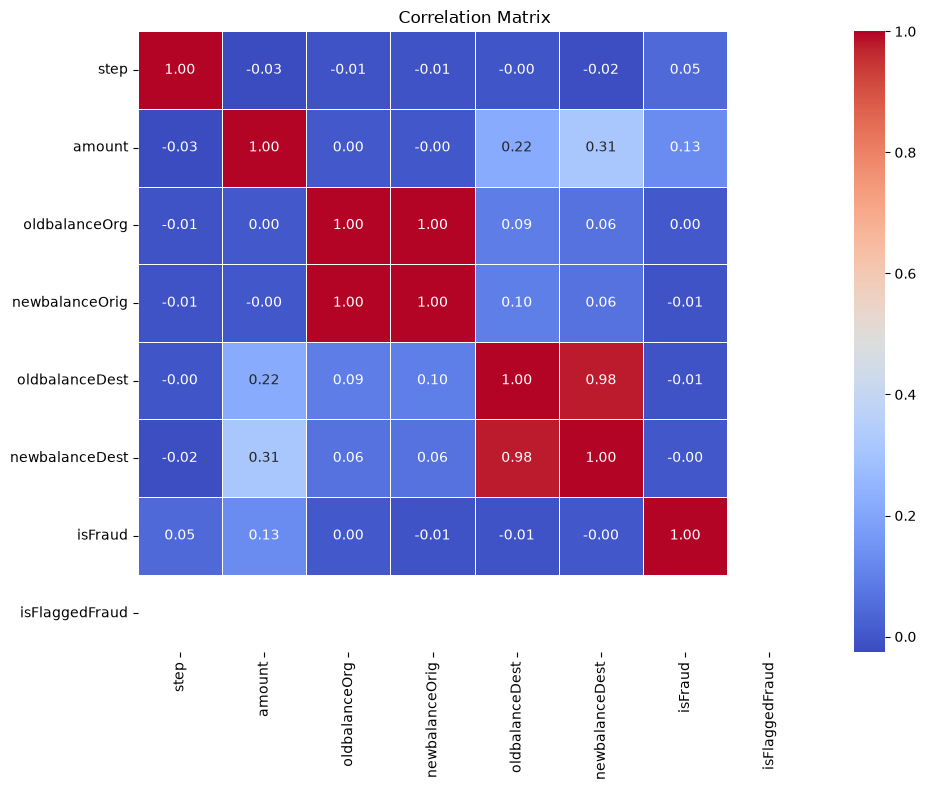

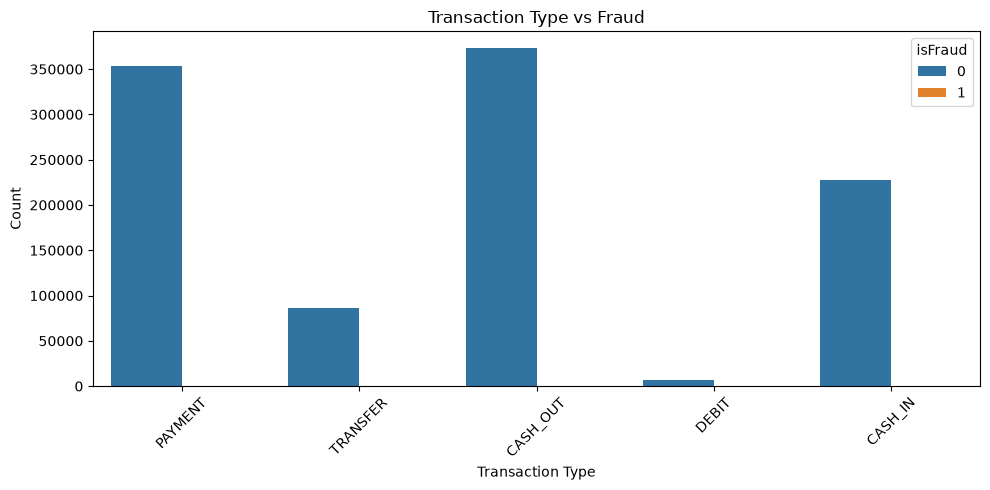

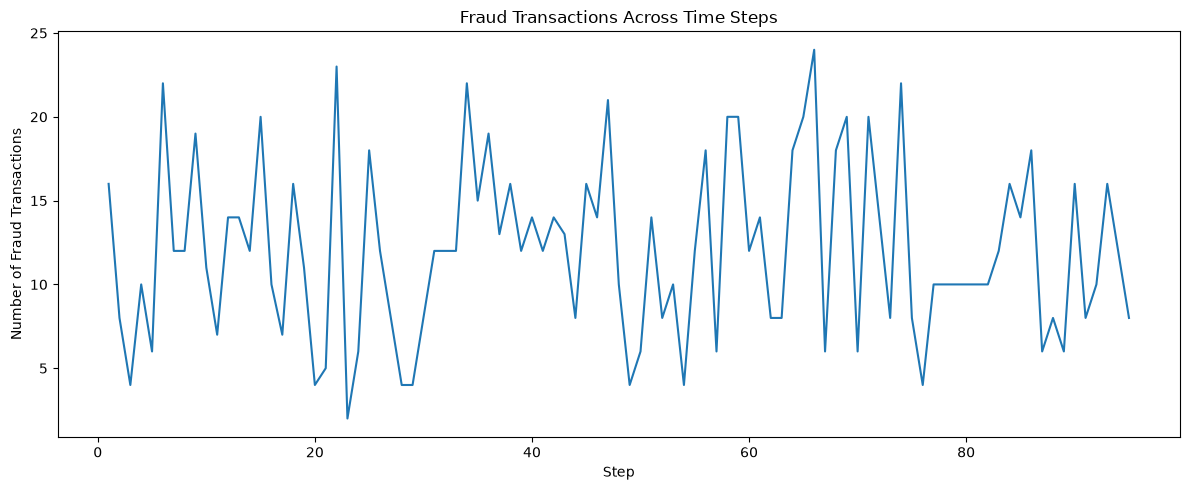

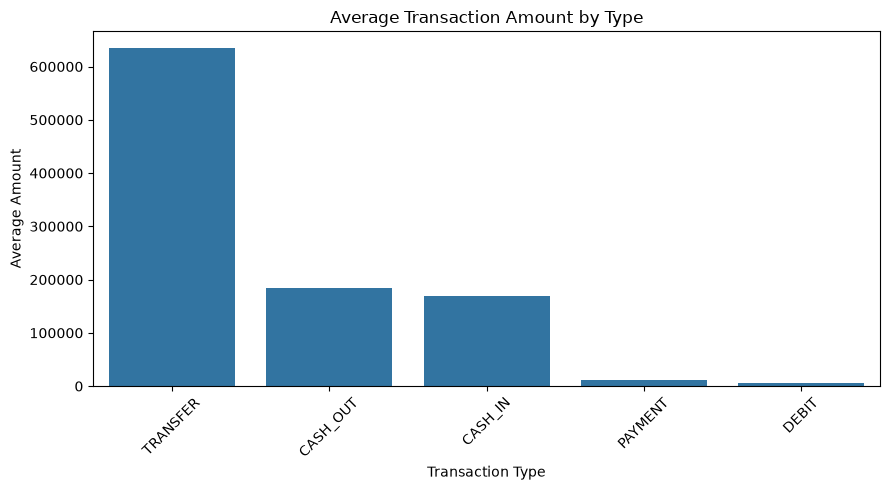

               amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
isFraud                                                                
0        1.575397e+05   8.736338e+05   894746.395080   978732.769117   
1        1.192629e+06   1.218636e+06    33944.321208   452866.124527   

         newbalanceDest  
isFraud                  
0          1.114237e+06  
1          1.077940e+06  
type
CASH_OUT    578
TRANSFER    564
Name: count, dtype: int64
              step        amount  oldbalanceOrg  newbalanceOrig  \
count  1142.000000  1.142000e+03   1.142000e+03    1.142000e+03   
mean     48.272329  1.192629e+06   1.218636e+06    3.394432e+04   
std      26.868203  2.030599e+06   2.229806e+06    5.012930e+05   
min       1.000000  1.190000e+02   0.000000e+00    0.000000e+00   
25%      25.000000  8.607017e+04   7.802889e+04    0.000000e+00   
50%      48.000000  3.531794e+05   3.487051e+05    0.000000e+00   
75%      70.750000  1.248759e+06   1.218166e+06    0.000000e+00   
max     

In [11]:
print(df["type"].value_counts())
print(df["isFraud"].value_counts())
print(df["isFlaggedFraud"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="type")
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
sns.countplot(data=df, x="isFraud")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
sns.countplot(data=df, x="isFlaggedFraud")
plt.title("Flagged vs Non-Flagged Transactions")
plt.xlabel("isFlaggedFraud")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fraud_type = pd.crosstab(df["type"], df["isFraud"])

fraud_type.plot(kind="bar", figsize=(9,5))
plt.title("Fraud Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fraud_rate = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.histplot(data=df, x="amount", bins=100, log_scale=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.histplot(data=df[df["isFraud"] == 0], x="amount", bins=100, log_scale=True, stat="density", alpha=0.5)
sns.histplot(data=df[df["isFraud"] == 1], x="amount", bins=100, log_scale=True, stat="density", alpha=0.5)
plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="amount")
plt.yscale("log")
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="oldbalanceOrg")
plt.yscale("log")
plt.title("Sender Old Balance by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("oldbalanceOrg")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="newbalanceOrig")
plt.yscale("log")
plt.title("Sender New Balance by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("newbalanceOrig")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="oldbalanceDest")
plt.yscale("log")
plt.title("Receiver Old Balance by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("oldbalanceDest")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="newbalanceDest")
plt.yscale("log")
plt.title("Receiver New Balance by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("newbalanceDest")
plt.tight_layout()
plt.show()

numeric_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="type", hue="isFraud")
plt.title("Transaction Type vs Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

step_fraud = df.groupby("step")["isFraud"].sum()

plt.figure(figsize=(12,5))
plt.plot(step_fraud.index, step_fraud.values)
plt.title("Fraud Transactions Across Time Steps")
plt.xlabel("Step")
plt.ylabel("Number of Fraud Transactions")
plt.tight_layout()
plt.show()

avg_amount = df.groupby("type")["amount"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=avg_amount.index, y=avg_amount.values)
plt.title("Average Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fraud_summary = df.groupby("isFraud")[[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]].mean()

print(fraud_summary)

print(df[df["isFraud"] == 1]["type"].value_counts())
print(df[df["isFraud"] == 1][numeric_cols].describe())

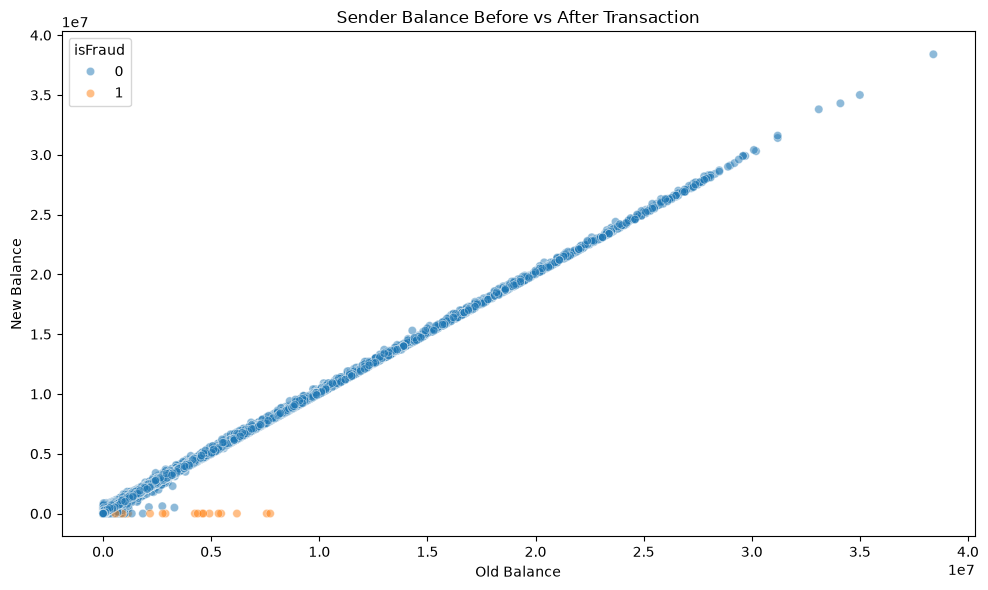

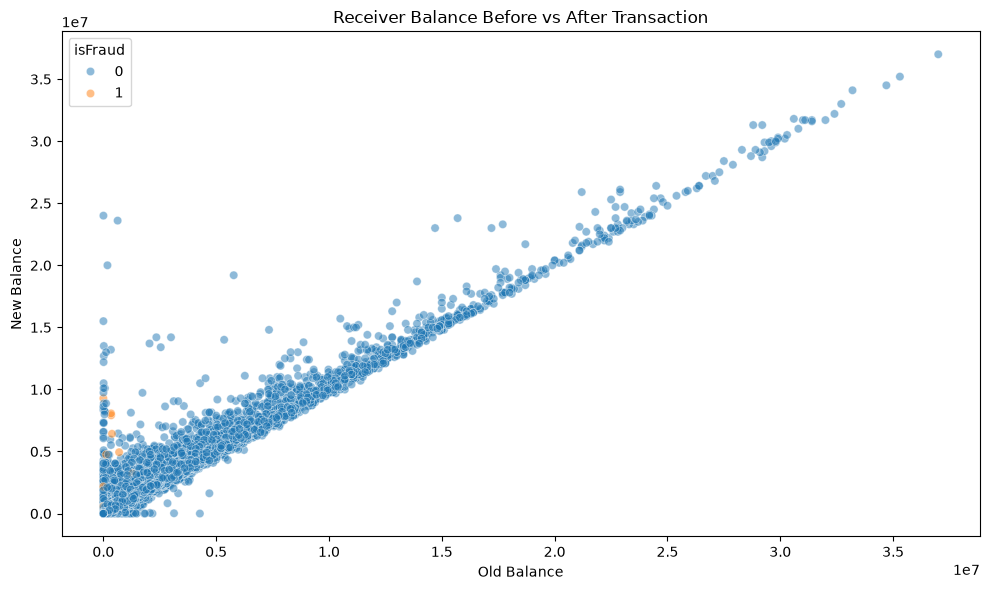

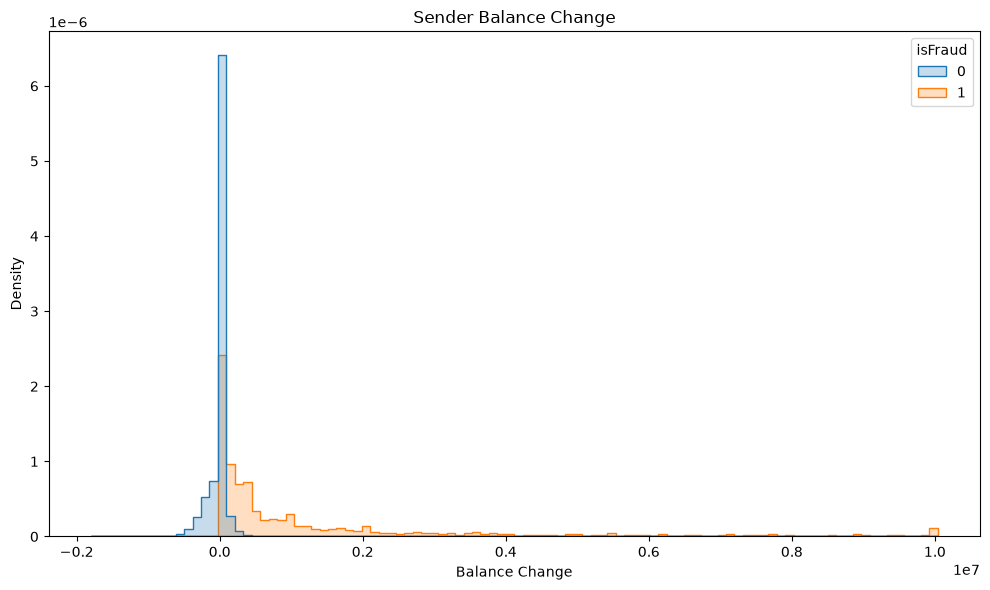

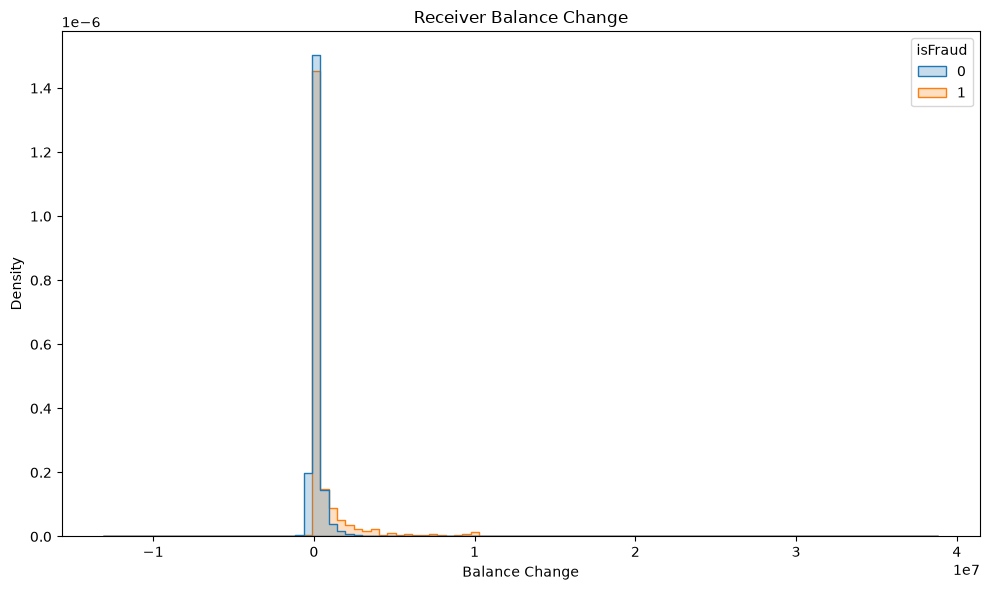

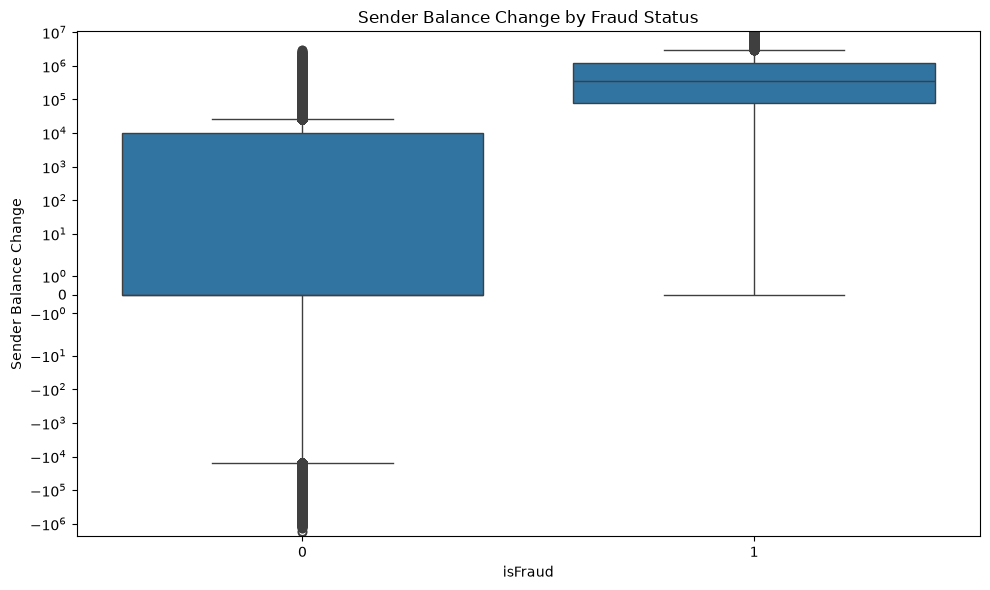

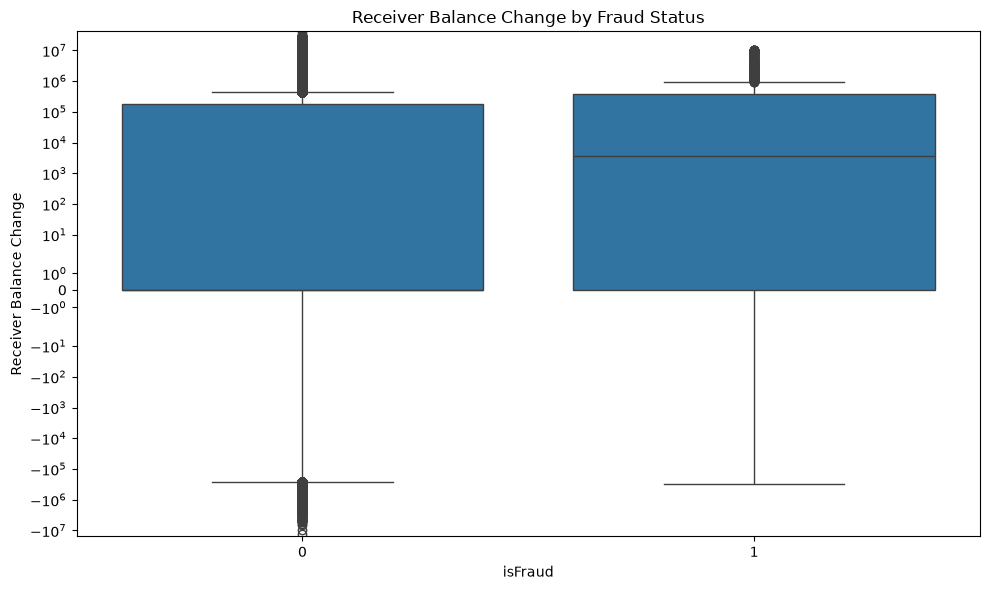

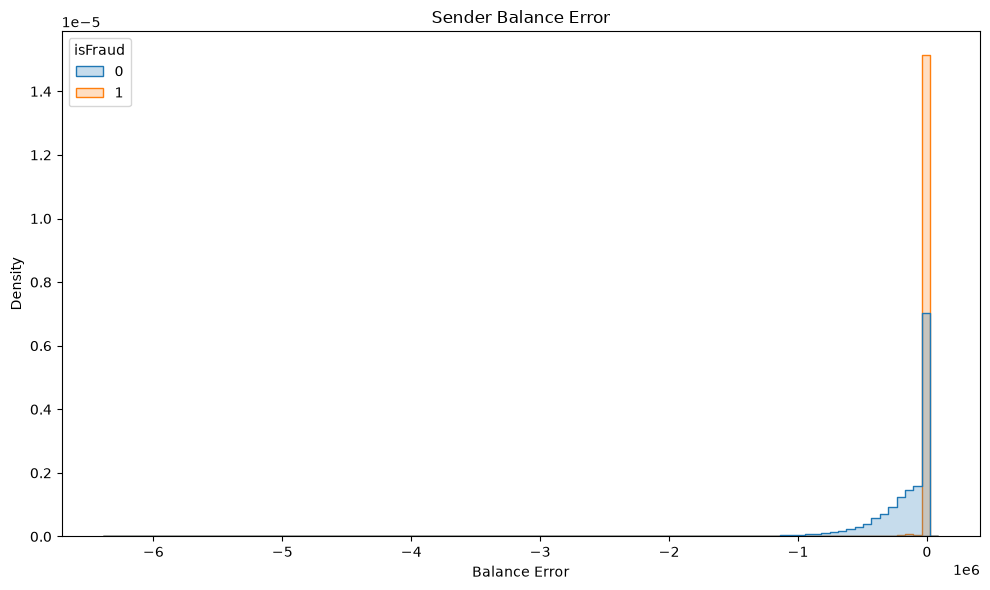

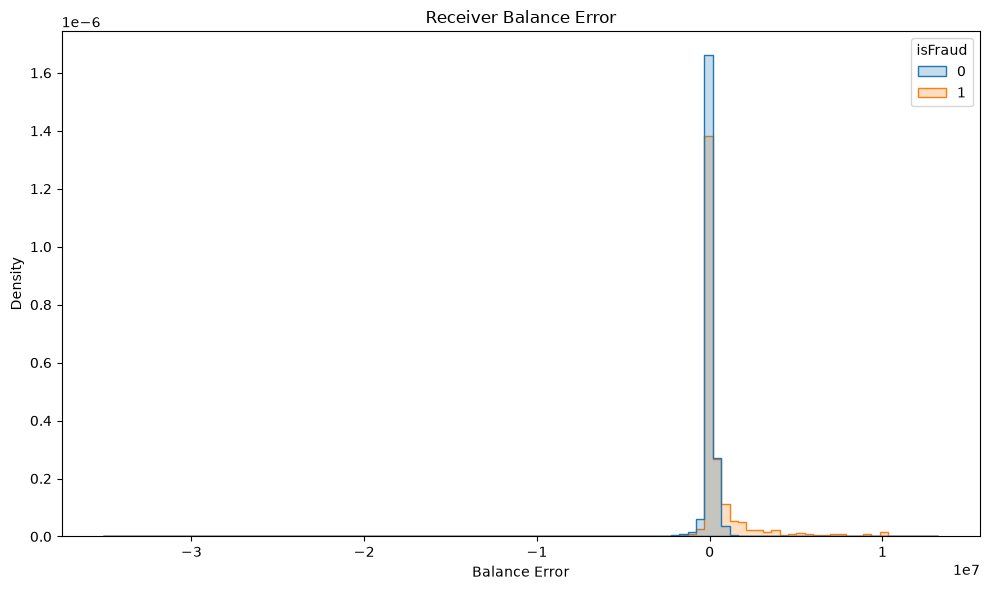

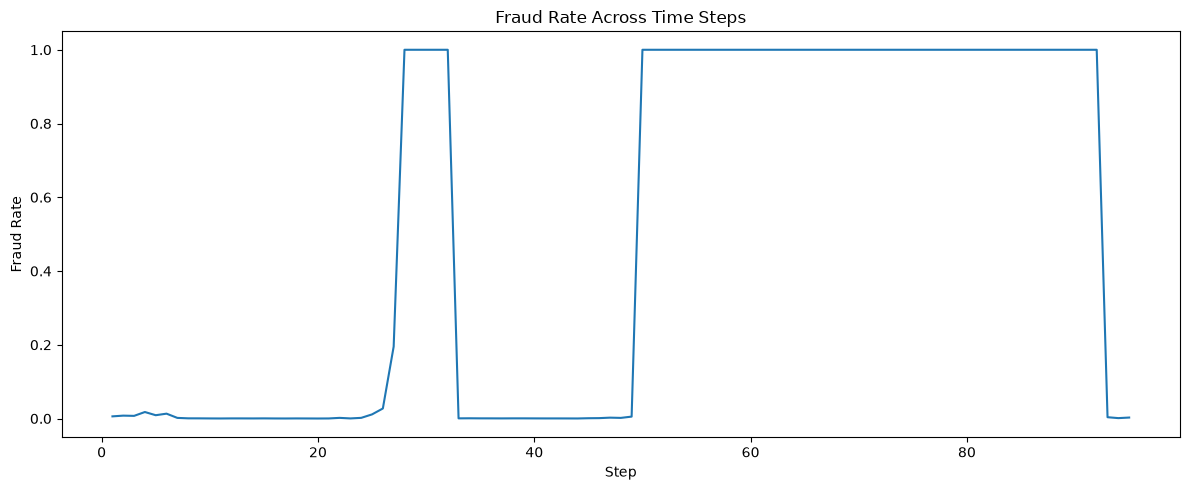

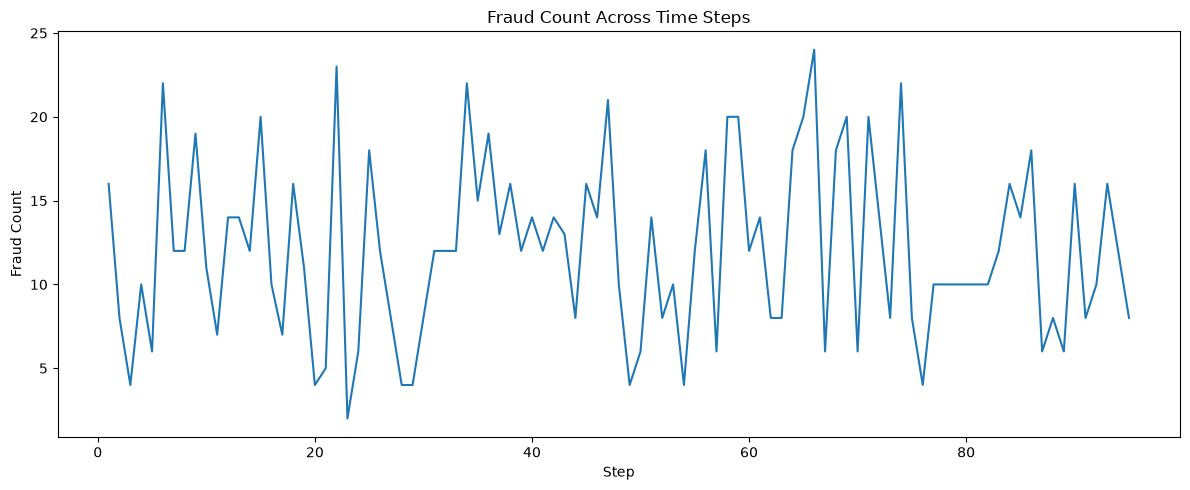

          transactions  fraud_count  fraud_rate  average_amount  total_amount
type                                                                         
TRANSFER         86753          564    0.006501   634403.832422  5.503644e+10
CASH_OUT        373641          578    0.001547   184039.592505  6.876474e+10
CASH_IN         227130            0    0.000000   169923.648522  3.859476e+10
DEBIT             7178            0    0.000000     5878.516989  4.219599e+07
PAYMENT         353873            0    0.000000    11122.907151  3.936097e+09


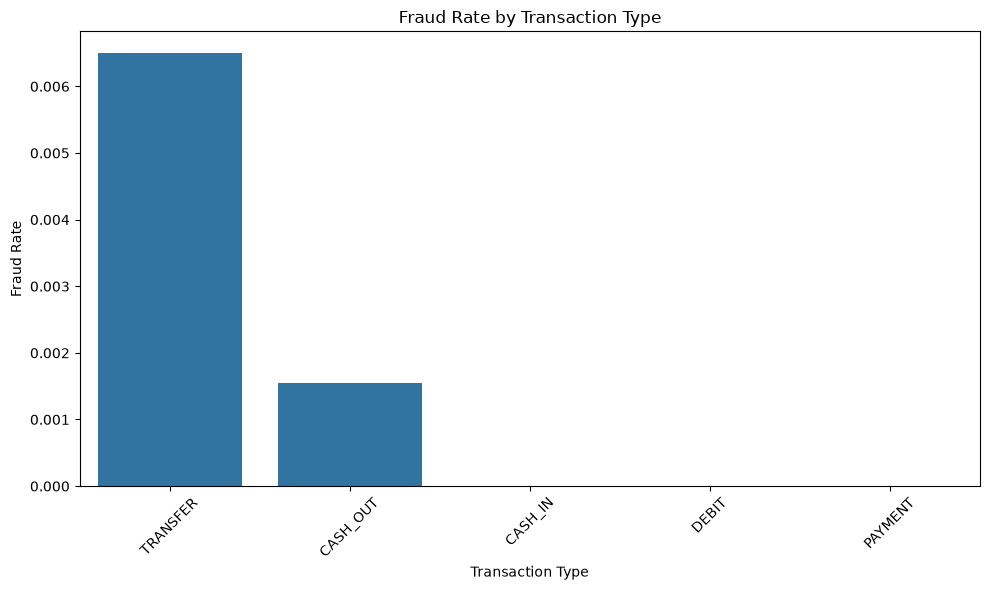

isFlaggedFraud    0
isFraud            
0               1.0
1               1.0


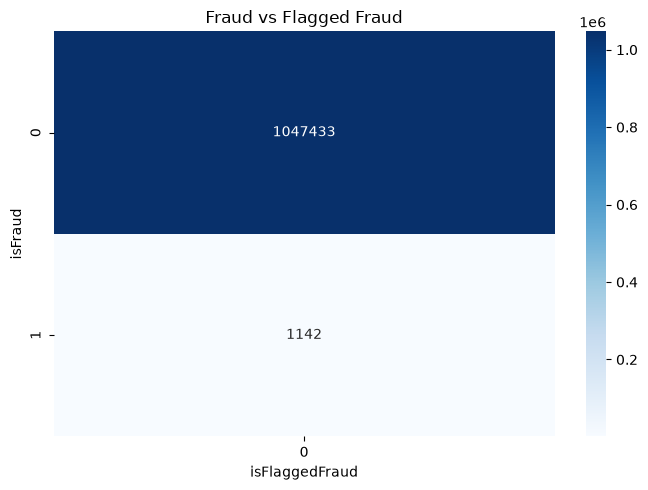

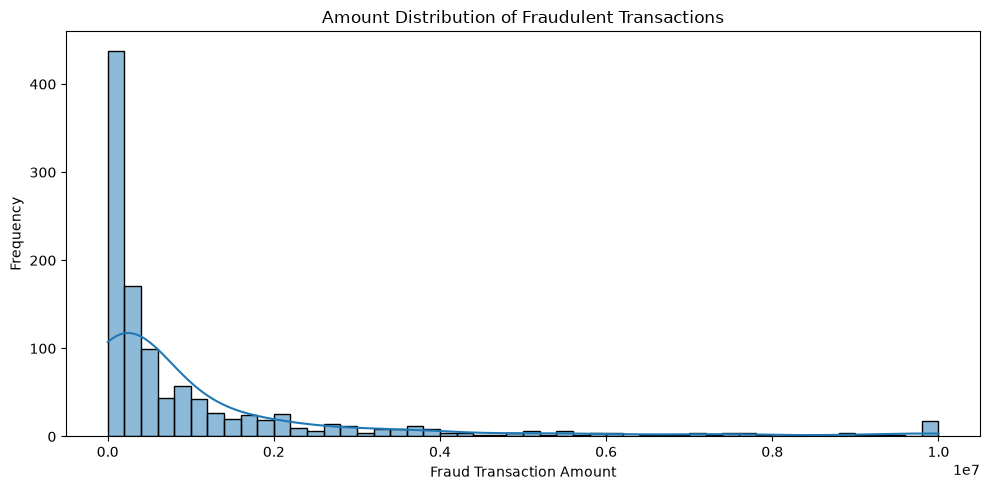

             transactions  total_amount  fraud_count
nameOrig                                            
C824646662              1   10000000.00            1
C53057884               1   10000000.00            1
C1079335762             1   10000000.00            1
C538142346              1   10000000.00            1
C792651637              1   10000000.00            1
C351297720              1   10000000.00            1
C1843531771             1   10000000.00            1
C2050703310             1   10000000.00            1
C29118015               1   10000000.00            1
C1438388258             1   10000000.00            1
C7162498                1   10000000.00            1
C1439740840             1   10000000.00            1
C416779475              1   10000000.00            1
C1237313447             1   10000000.00            1
C154757729              1    9977761.05            1
C840795008              1    9977761.05            1
C1548903046             1    9887819.06       

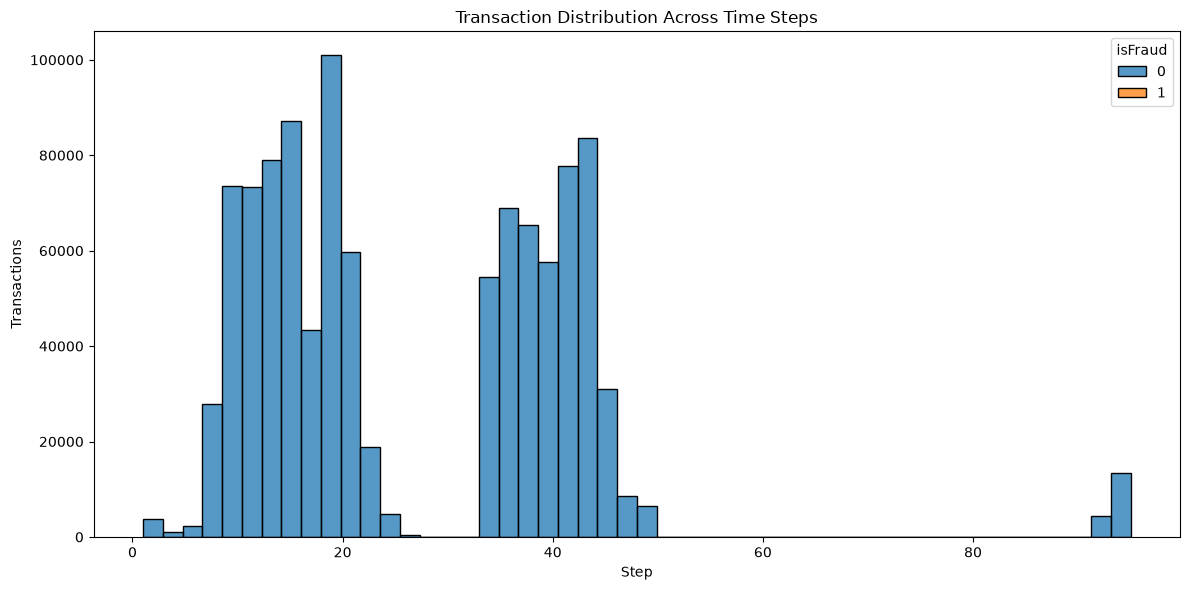

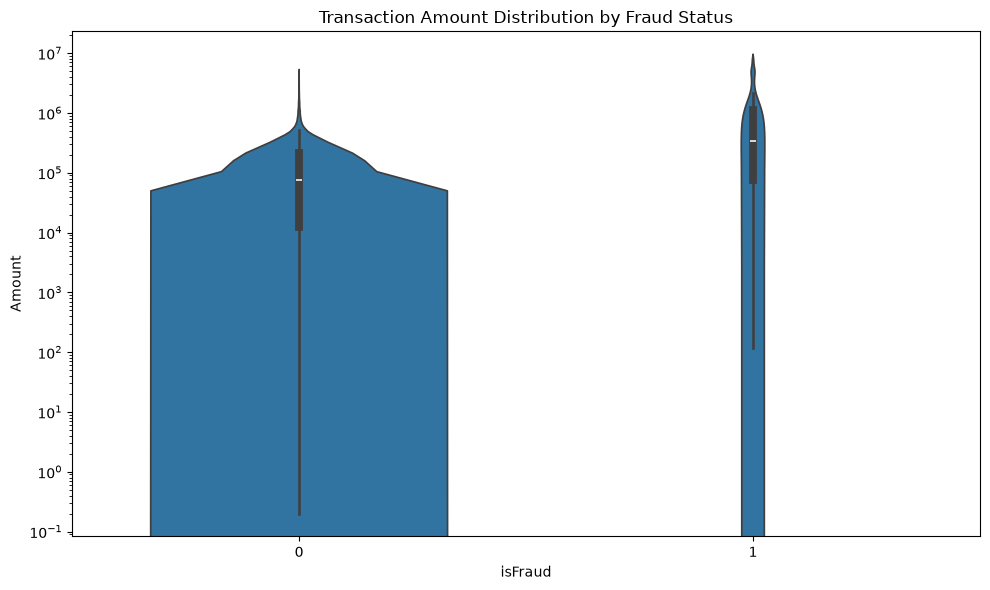

Fraud Percentage:
isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64


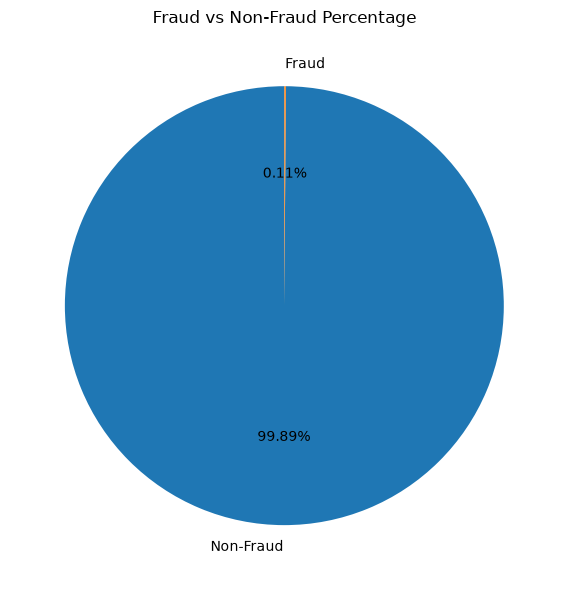

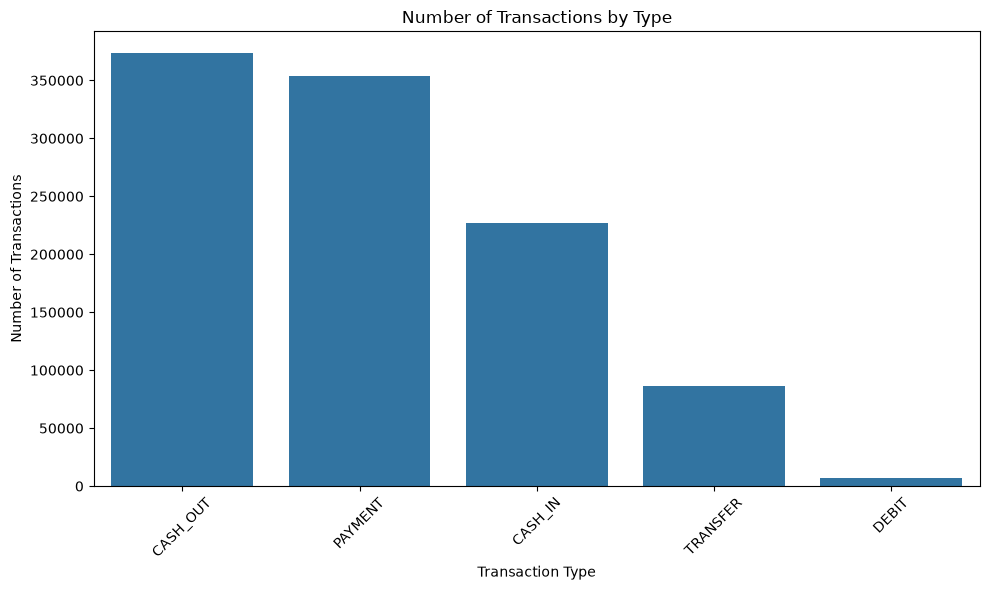

Final Dataset Shape: (1048575, 15)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
0  M1979787155             0.0             0.0        0               0   
1  M2044282225             0.0             0.0        0               0   
2   C553264065             0.0             0.0        1               0   
3    C38997010         21182.0             0.0        1               0   
4  M1230701703             0.0             0.0        0               0   

   sender_balance_change  receiver_balance_change  balance_erro

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(min(50000, len(df)), random_state=42),
    x="oldbalanceOrg",
    y="newbalanceOrig",
    hue="isFraud",
    alpha=0.5
)
plt.title("Sender Balance Before vs After Transaction")
plt.xlabel("Old Balance")
plt.ylabel("New Balance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(min(50000, len(df)), random_state=42),
    x="oldbalanceDest",
    y="newbalanceDest",
    hue="isFraud",
    alpha=0.5
)
plt.title("Receiver Balance Before vs After Transaction")
plt.xlabel("Old Balance")
plt.ylabel("New Balance")
plt.tight_layout()
plt.show()

df["sender_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["receiver_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["balance_error_orig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["balance_error_dest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="sender_balance_change",
    hue="isFraud",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Sender Balance Change")
plt.xlabel("Balance Change")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="receiver_balance_change",
    hue="isFraud",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Receiver Balance Change")
plt.xlabel("Balance Change")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="sender_balance_change")
plt.yscale("symlog")
plt.title("Sender Balance Change by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("Sender Balance Change")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="isFraud", y="receiver_balance_change")
plt.yscale("symlog")
plt.title("Receiver Balance Change by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("Receiver Balance Change")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="balance_error_orig",
    hue="isFraud",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Sender Balance Error")
plt.xlabel("Balance Error")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="balance_error_dest",
    hue="isFraud",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Receiver Balance Error")
plt.xlabel("Balance Error")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

fraud_by_step = df.groupby("step").agg(
    transactions=("isFraud", "size"),
    fraud_count=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
    total_amount=("amount", "sum")
).reset_index()

plt.figure(figsize=(12,5))
plt.plot(
    fraud_by_step["step"],
    fraud_by_step["fraud_rate"]
)
plt.title("Fraud Rate Across Time Steps")
plt.xlabel("Step")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(
    fraud_by_step["step"],
    fraud_by_step["fraud_count"]
)
plt.title("Fraud Count Across Time Steps")
plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.tight_layout()
plt.show()

type_summary = df.groupby("type").agg(
    transactions=("isFraud", "size"),
    fraud_count=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
    average_amount=("amount", "mean"),
    total_amount=("amount", "sum")
).sort_values("fraud_rate", ascending=False)

print(type_summary)

plt.figure(figsize=(10,6))
sns.barplot(
    data=type_summary.reset_index(),
    x="type",
    y="fraud_rate"
)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fraud_flag = pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    normalize="index"
)

print(fraud_flag)

plt.figure(figsize=(7,5))
sns.heatmap(
    pd.crosstab(df["isFraud"], df["isFlaggedFraud"]),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Fraud vs Flagged Fraud")
plt.xlabel("isFlaggedFraud")
plt.ylabel("isFraud")
plt.tight_layout()
plt.show()

fraud_amount = df[df["isFraud"] == 1]["amount"]

plt.figure(figsize=(10,5))
sns.histplot(
    fraud_amount,
    bins=50,
    kde=True
)
plt.title("Amount Distribution of Fraudulent Transactions")
plt.xlabel("Fraud Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

top_orig = df.groupby("nameOrig").agg(
    transactions=("amount", "size"),
    total_amount=("amount", "sum"),
    fraud_count=("isFraud", "sum")
).sort_values("total_amount", ascending=False).head(20)

print(top_orig)

top_dest = df.groupby("nameDest").agg(
    transactions=("amount", "size"),
    total_amount=("amount", "sum"),
    fraud_count=("isFraud", "sum")
).sort_values("total_amount", ascending=False).head(20)

print(top_dest)

duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

print(
    df.isnull().sum().sort_values(ascending=False)
)

outlier_summary = {}

for col in [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = count

print(pd.Series(outlier_summary))

plt.figure(figsize=(12,6))
sns.histplot(
    data=df,
    x="step",
    hue="isFraud",
    bins=50,
    multiple="stack"
)
plt.title("Transaction Distribution Across Time Steps")
plt.xlabel("Step")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.violinplot(
    data=df.sample(min(50000, len(df)), random_state=42),
    x="isFraud",
    y="amount"
)
plt.yscale("log")
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

fraud_percentage = df["isFraud"].value_counts(normalize=True) * 100

print("Fraud Percentage:")
print(fraud_percentage)

plt.figure(figsize=(6,6))
plt.pie(
    df["isFraud"].value_counts(),
    labels=["Non-Fraud", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Fraud vs Non-Fraud Percentage")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(
    x=df["type"].value_counts().index,
    y=df["type"].value_counts().values
)
plt.title("Number of Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Final Dataset Shape:", df.shape)
print(df.head())

Original training distribution:
isFraud
0    837946
1       914
Name: count, dtype: int64

Original testing distribution:
isFraud
0    209487
1       228
Name: count, dtype: int64

After SMOTE:
isFraud
0    837946
1    837946
Name: count, dtype: int64

Logistic Regression
Accuracy  : 0.9376
Precision : 0.0157
Recall    : 0.9167
F1-Score  : 0.0310
ROC-AUC   : 0.9759
PR-AUC     : 0.4365

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.94      0.97    209487
       Fraud       0.02      0.92      0.03       228

    accuracy                           0.94    209715
   macro avg       0.51      0.93      0.50    209715
weighted avg       1.00      0.94      0.97    209715


Decision Tree
Accuracy  : 0.9993
Precision : 0.6267
Recall    : 0.9868
F1-Score  : 0.7666
ROC-AUC   : 0.9934
PR-AUC     : 0.9835

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    20948

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Logistic Regression,0.937630,0.015750,0.916667,0.030968,0.975914,0.436507
Decision Tree,0.999347,0.626741,0.986842,0.766610,0.993414,0.983543


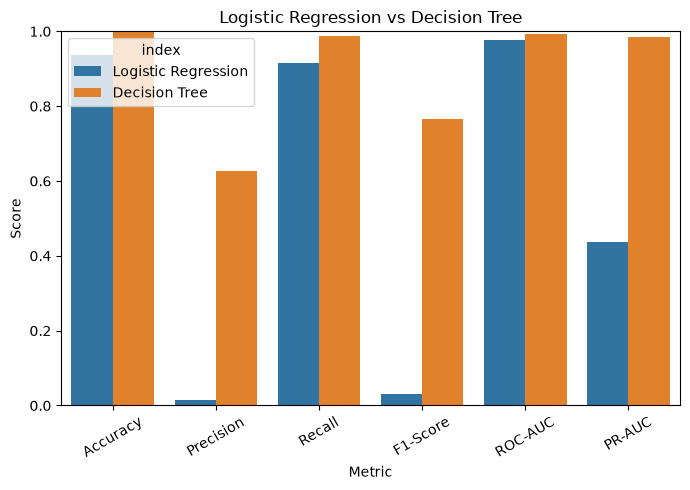

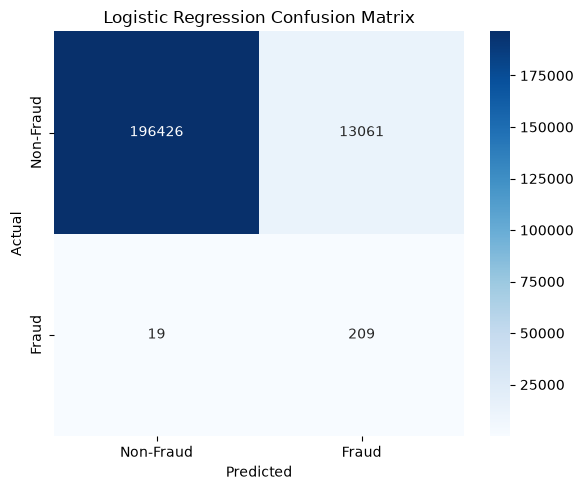

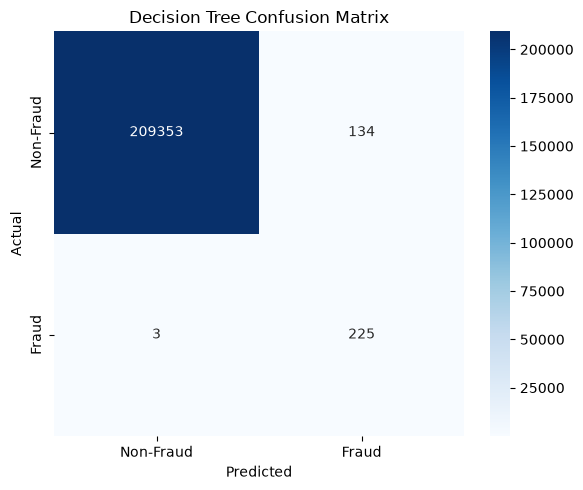

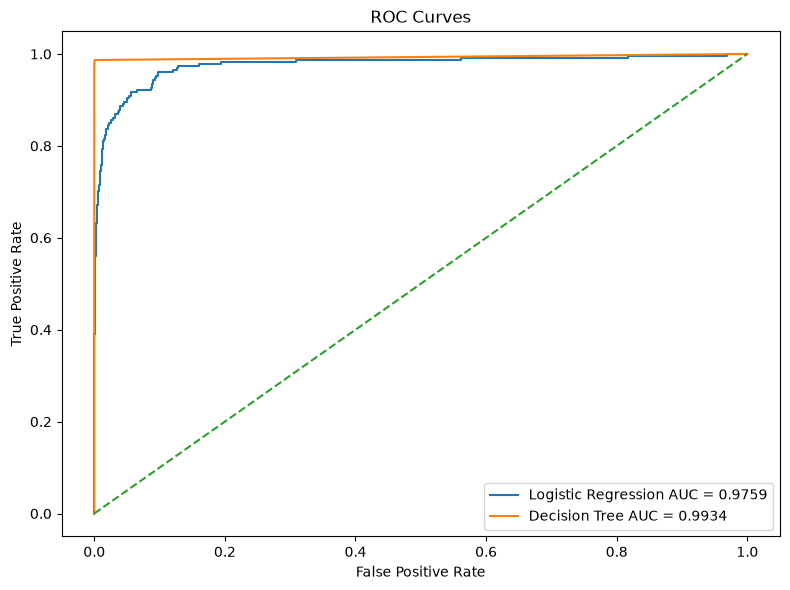

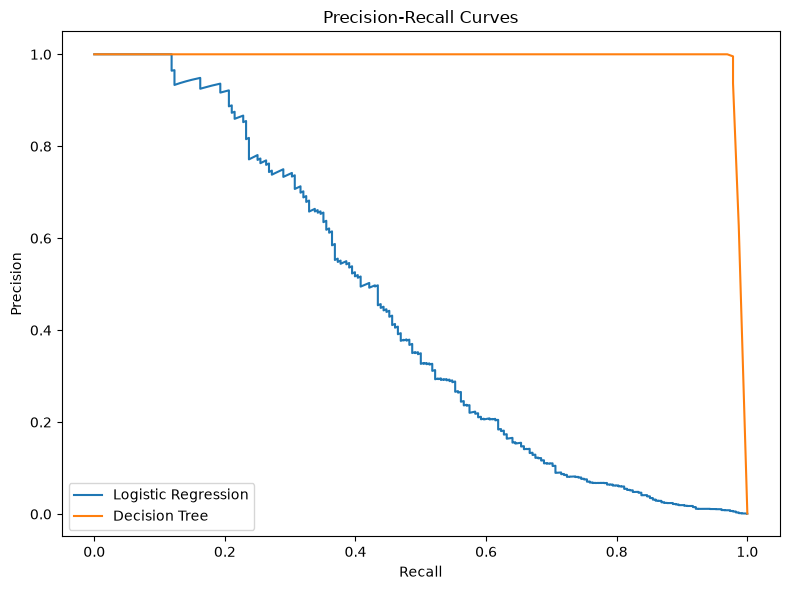


Decision Tree Feature Importance:


,Feature,Importance
9,balance_error_orig,0.602114
3,newbalanceOrig,0.346502
2,oldbalanceOrg,0.016361
7,sender_balance_change,0.014676
1,amount,0.004077
0,step,0.003331
10,balance_error_dest,0.003306
8,receiver_balance_change,0.002994
4,oldbalanceDest,0.002836
5,newbalanceDest,0.002333


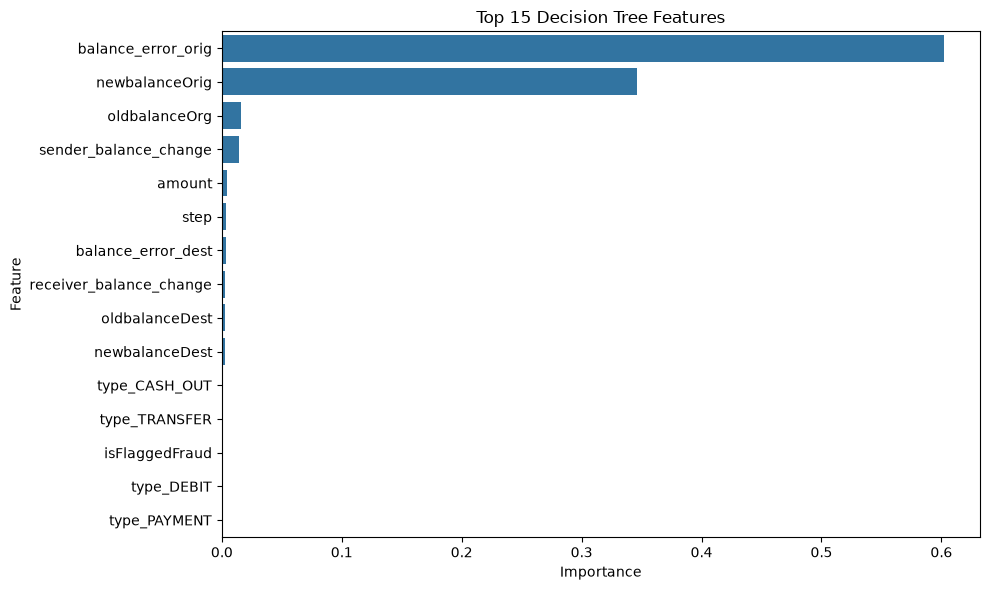


Top Logistic Regression Features:


,Feature,Coefficient,Absolute_Coefficient
13,type_PAYMENT,-4.648284,4.648284
14,type_TRANSFER,2.572307,2.572307
2,oldbalanceOrg,-0.942287,0.942287
3,newbalanceOrig,-0.924200,0.924200
1,amount,0.612592,0.612592
11,type_CASH_OUT,0.584439,0.584439
0,step,0.435884,0.435884
4,oldbalanceDest,-0.354354,0.354354
5,newbalanceDest,-0.279074,0.279074
12,type_DEBIT,-0.192530,0.192530


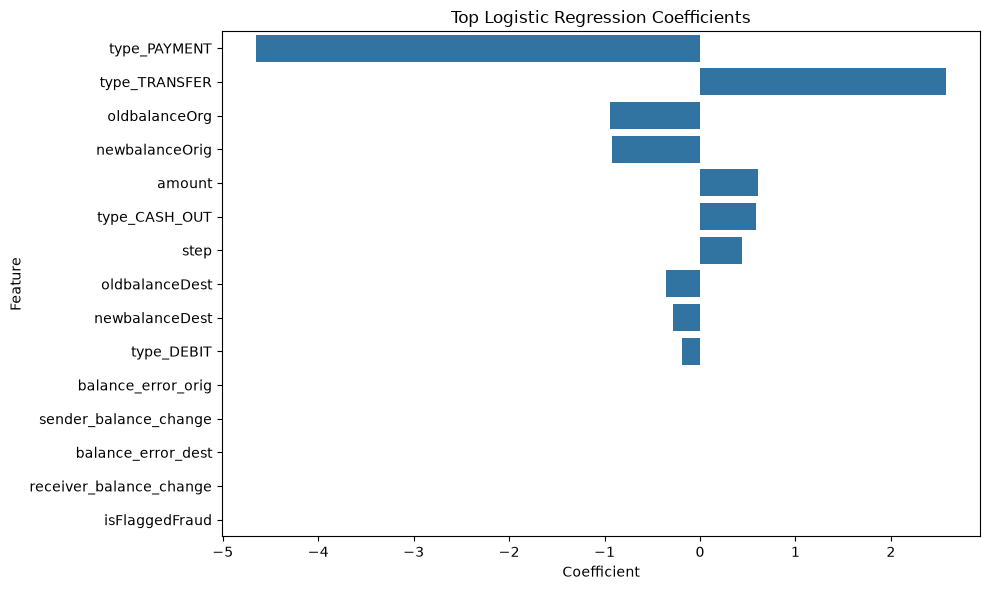

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

data = df.copy()

data = data.drop(columns=["nameOrig", "nameDest"], errors="ignore")

data = pd.get_dummies(
    data,
    columns=["type"],
    drop_first=True,
    dtype=int
)

X = data.drop(columns=["isFraud"])
y = data["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Original training distribution:")
print(y_train.value_counts())

print("\nOriginal testing distribution:")
print(y_test.value_counts())

numeric_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

available_numeric = [
    col for col in numeric_features
    if col in X_train.columns
]

X_train_scaled[available_numeric] = scaler.fit_transform(
    X_train[available_numeric]
)

X_test_scaled[available_numeric] = scaler.transform(
    X_test[available_numeric]
)

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = logistic_model.predict(X_test_scaled)
lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

decision_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

dt_pred = decision_tree.predict(X_test)
dt_prob = decision_tree.predict_proba(X_test)[:, 1]

def evaluate_model(name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Non-Fraud", "Fraud"],
            zero_division=0
        )
    )

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]

lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

results = pd.DataFrame(
    [lr_results, dt_results],
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    index=[
        "Logistic Regression",
        "Decision Tree"
    ]
)

print("\nModel Comparison:")
display(results)

plt.figure(figsize=(7,5))
sns.barplot(
    data=results.reset_index().melt(
        id_vars="index",
        var_name="Metric",
        value_name="Score"
    ),
    x="Metric",
    y="Score",
    hue="index"
)
plt.title("Logistic Regression vs Decision Tree")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

plt.figure(figsize=(8,6))
plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression AUC = {roc_auc_score(y_test, lr_prob):.4f}"
)
plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree AUC = {roc_auc_score(y_test, dt_prob):.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    lr_prob
)

dt_precision, dt_recall, _ = precision_recall_curve(
    y_test,
    dt_prob
)

plt.figure(figsize=(8,6))
plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression"
)
plt.plot(
    dt_recall,
    dt_precision,
    label="Decision Tree"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("\nDecision Tree Feature Importance:")
display(feature_importance.head(15))

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Decision Tree Features")
plt.tight_layout()
plt.show()

coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coef["Absolute_Coefficient"] = np.abs(
    coef["Coefficient"]
)

coef = coef.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\nTop Logistic Regression Features:")
display(coef.head(15))

plt.figure(figsize=(10,6))
sns.barplot(
    data=coef.head(15),
    x="Coefficient",
    y="Feature"
)
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()